In [22]:
import itertools

import numpy as np
import pandas as pd
import yfinance as yf
import random
%matplotlib inline
import matplotlib.pyplot as plt

import torch
from stable_baselines3.common.utils import set_random_seed

from finrl import config_tickers
from finrl.config import INDICATORS, TRAIN_START_DATE, TRAIN_END_DATE, TRADE_START_DATE, TRADE_END_DATE
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent
from pypfopt.efficient_frontier import EfficientFrontier

## Reinforcement Learning

In [23]:
tickers = ["AAPL", "MSFT", "JPM", "XOM", "KO"]

train_start = "2018-01-01"
train_end   = "2023-01-01"  
test_start  = "2023-01-01"
test_end    = "2025-01-01"  

In [24]:
train_raw = yf.download(
    tickers=tickers,
    start=train_start,
    end=train_end,
    interval="1d",
    auto_adjust=True,
    group_by="ticker",
    progress=False
)

trade_raw = yf.download(
    tickers=tickers,
    start=test_start,
    end=test_end,
    interval="1d",
    auto_adjust=True,
    group_by="ticker",
    progress=False)

In [25]:
train_raw.head

<bound method NDFrame.head of Ticker            XOM                                                   MSFT  \
Price            Open       High        Low      Close    Volume        Open   
Date                                                                           
2018-01-02  57.746799  58.697532  57.636572  58.580414  11469300   79.035558   
2018-01-03  58.669989  59.916966  58.435747  59.730949  13957700   78.971313   
2018-01-04  59.792950  60.089194  59.544932  59.813618  10863000   79.457643   
2018-01-05  59.765411  59.854971  59.048915  59.765411  11047600   80.439514   
2018-01-08  59.730950  60.040975  59.662057  60.034084  10927100   80.935034   
...               ...        ...        ...        ...       ...         ...   
2022-12-23  95.828444  97.432306  95.783648  97.378548  11539400  230.071553   
2022-12-27  97.907186  98.982404  97.512945  98.731522  11962100  232.595301   
2022-12-28  98.480645  98.561283  96.679659  97.109741  10702100  230.831627   
2022-12-29

In [26]:
trade_raw.head

<bound method NDFrame.head of Ticker             XOM                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2023-01-03   98.364151   98.579192   94.520261   95.434196  15146200   
2023-01-04   93.902034   96.016623   93.866193   95.711975  18058400   
2023-01-05   95.281876   98.516478   95.254997   97.853432  15946600   
2023-01-06   98.632961  100.344339   98.265593   99.036163  16348100   
2023-01-09  100.030739  100.030739   96.599013   97.190384  17964600   
...                ...         ...         ...         ...       ...   
2024-12-24  102.068640  102.710647  101.282907  101.953659   7807000   
2024-12-26  102.068639  102.557329  101.512882  102.039894   9652400   
2024-12-27  101.857841  103.477213  101.349983  102.030319  11943900   
2024-12-30  101.857836  102.106965  101.100848  101.340401  11080800   
2024-12-31  101.733271  103.390979

In [27]:
def process_yf_to_finrl(df, tickers):
    temp_df = df.stack(level=0).reset_index()
    temp_df.columns = ['date', 'tic', 'open', 'high', 'low', 'close', 'volume']

    temp_df['date'] = temp_df['date'].dt.strftime('%Y-%m-%d')
    return temp_df


train_processed_raw = process_yf_to_finrl(train_raw, tickers)
trade_processed_raw = process_yf_to_finrl(trade_raw, tickers)

/var/folders/30/55gv15g12_7bkbzy405jqcxr0000gn/T/ipykernel_62827/2626236642.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  temp_df = df.stack(level=0).reset_index()
/var/folders/30/55gv15g12_7bkbzy405jqcxr0000gn/T/ipykernel_62827/2626236642.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  temp_df = df.stack(level=0).reset_index()


In [28]:
fe = FeatureEngineer(
    use_technical_indicator=True,
    tech_indicator_list=INDICATORS,  
    use_vix=False,                  
    use_turbulence=False,            
    user_defined_feature=False,
)


train_fe = fe.preprocess_data(train_processed_raw)
trade_fe = fe.preprocess_data(trade_processed_raw)

Successfully added technical indicators
Successfully added technical indicators


In [29]:


def clean_data(df):
    list_ticker = df["tic"].unique().tolist()
    list_date = list(pd.date_range(df["date"].min(), df["date"].max()).astype(str))
    
    combination = list(itertools.product(list_date, list_ticker))
    processed_full = pd.DataFrame(combination, columns=["date", "tic"])
    

    processed_full = processed_full.merge(df, on=["date", "tic"], how="left")
    processed_full = processed_full[processed_full["date"].isin(df["date"])]
    processed_full = processed_full.sort_values(["date", "tic"])
    processed_full = processed_full.fillna(0)  #
    return processed_full

train_final = clean_data(train_fe)
trade_final = clean_data(trade_fe)

In [30]:

train_final.index = train_final["date"].factorize()[0]
trade_final.index = trade_final["date"].factorize()[0]

In [31]:


def set_global_seed(seed=123):

    random.seed(seed)
    

    np.random.seed(seed)
    
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    set_random_seed(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
set_global_seed(123)

In [32]:
stock_dimension = len(train_final["tic"].unique())
state_space = 1 + 2 * stock_dimension + len(INDICATORS) * stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")

env_kwargs = {
    "hmax": 100,
    "initial_amount": 1000000,
    "num_stock_shares": [0] * stock_dimension,
    "buy_cost_pct": [0.001] * stock_dimension,
    "sell_cost_pct": [0.001] * stock_dimension,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": INDICATORS,
    "action_space": stock_dimension,
    "reward_scaling": 1e-4
}

e_train_gym = StockTradingEnv(df=train_final, **env_kwargs)
env_train, _ = e_train_gym.get_sb_env()


Stock Dimension: 5, State Space: 51


In [33]:
agent = DRLAgent(env=env_train)

model_a2c = agent.get_model("a2c")
trained_a2c = agent.train_model(model=model_a2c, tb_log_name="a2c", total_timesteps=10000)


{'n_steps': 5, 'ent_coef': 0.01, 'learning_rate': 0.0007}
Using cpu device
---------------------------------------
| time/                 |             |
|    fps                | 1685        |
|    iterations         | 100         |
|    time_elapsed       | 0           |
|    total_timesteps    | 500         |
| train/                |             |
|    entropy_loss       | -7.34       |
|    explained_variance | 0           |
|    learning_rate      | 0.0007      |
|    n_updates          | 99          |
|    policy_loss        | 0.0948      |
|    reward             | 0.011597741 |
|    std                | 1.05        |
|    value_loss         | 0.00063     |
---------------------------------------
-------------------------------------
| time/                 |           |
|    fps                | 1664      |
|    iterations         | 200       |
|    time_elapsed       | 0         |
|    total_timesteps    | 1000      |
| train/                |           |
|    entropy_loss  

In [34]:

PPO_PARAMS = {
    "n_steps": 2048,
    "ent_coef": 0.01,
    "learning_rate": 0.00025,
    "batch_size": 128,
}
model_ppo = agent.get_model("ppo", model_kwargs=PPO_PARAMS)
trained_ppo = agent.train_model(model=model_ppo, tb_log_name="ppo", total_timesteps=10000)

{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 128}
Using cpu device
day: 1258, episode: 10
begin_total_asset: 1000000.00
end_total_asset: 1167109.57
total_reward: 167109.57
total_cost: 36697.56
total_trades: 6086
Sharpe: 0.318
-----------------------------------
| time/              |            |
|    fps             | 2001       |
|    iterations      | 1          |
|    time_elapsed    | 1          |
|    total_timesteps | 2048       |
| train/             |            |
|    reward          | -1.1169002 |
-----------------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1933         |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0044219242 |
|    clip_fraction        | 0.0471       |
|    clip_range           | 0.2 

In [35]:
e_trade_gym_a2c = StockTradingEnv(df=trade_final, **env_kwargs)
e_trade_gym_ppo = StockTradingEnv(df=trade_final, **env_kwargs)

df_account_value_a2c, df_actions_a2c = DRLAgent.DRL_prediction(
    model=trained_a2c, 
    environment=e_trade_gym_a2c
)

df_account_value_ppo, df_actions_ppo = DRLAgent.DRL_prediction(
    model=trained_ppo, 
    environment=e_trade_gym_ppo
)

hit end!
hit end!


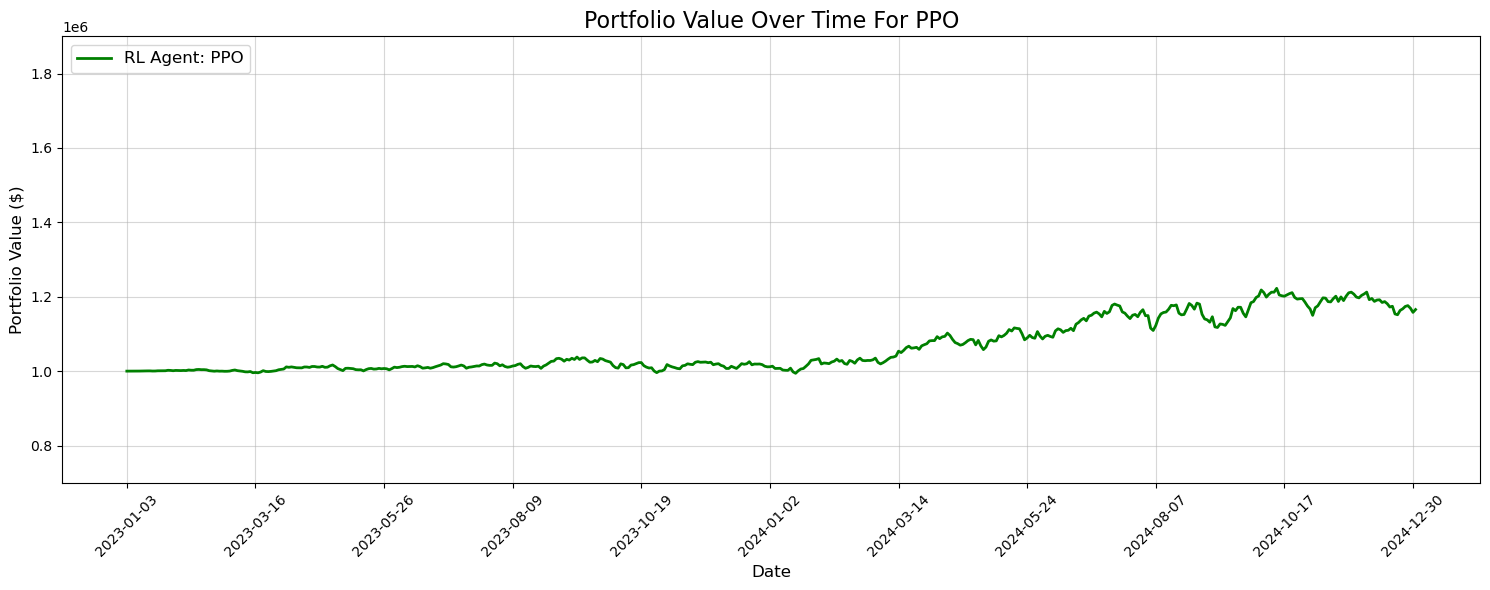

In [36]:
%matplotlib inline
result_df = df_account_value_ppo[["date", "account_value"]].rename(columns={"account_value": "PPO"})
plt.figure(figsize=(15, 6))
plt.plot(result_df["date"], result_df["PPO"], label="RL Agent: PPO", linewidth=2, color="green")
plt.title("Portfolio Value Over Time For PPO", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Portfolio Value ($)", fontsize=12)
plt.ylim(0.7e6, 1.9e6)
plt.legend(fontsize=12, loc="upper left")
plt.grid(True, alpha=0.5)

xticks_interval = max(1, len(result_df) // 10)
plt.xticks(result_df["date"][::xticks_interval], rotation=45)

plt.tight_layout()
plt.show()

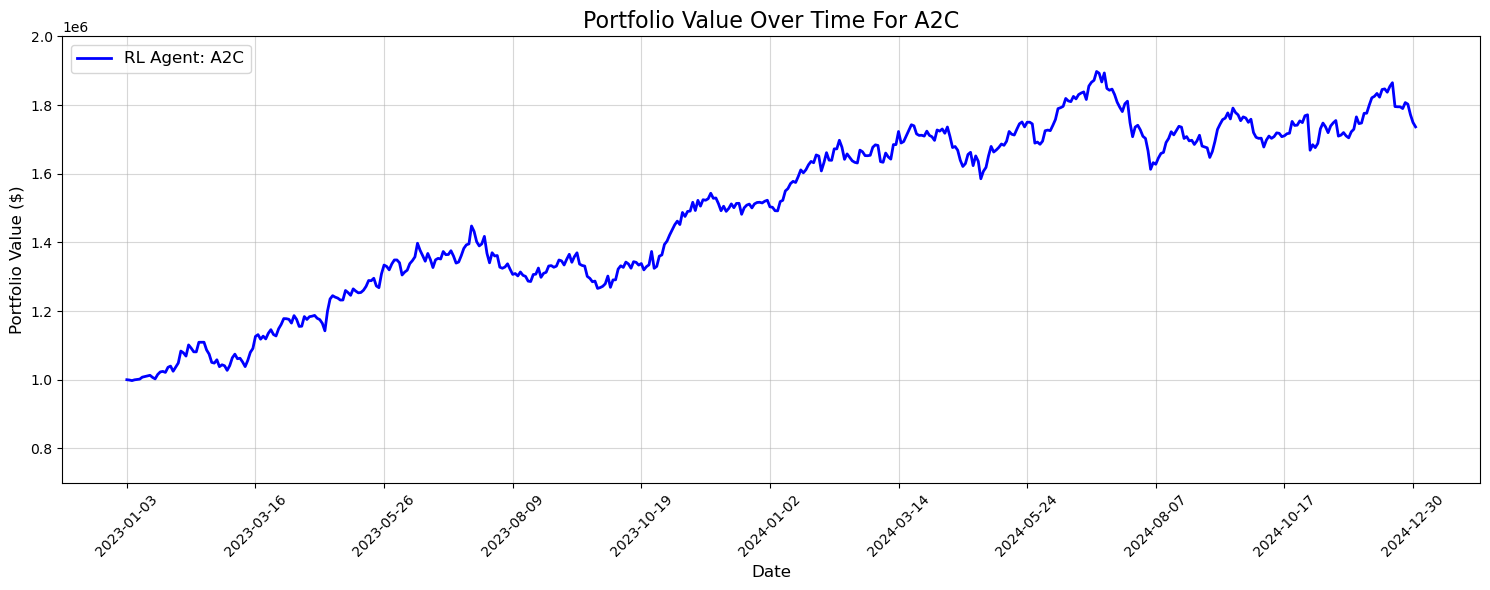

In [37]:
%matplotlib inline
result_df = df_account_value_a2c[["date", "account_value"]].rename(columns={"account_value": "A2C"})
plt.figure(figsize=(15, 6))
plt.plot(result_df["date"], result_df["A2C"], label="RL Agent: A2C", linewidth=2, color="blue")
plt.title("Portfolio Value Over Time For A2C", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Portfolio Value ($)", fontsize=12)
plt.ylim(0.7e6, 2e6)
plt.legend(fontsize=12, loc="upper left")
plt.grid(True, alpha=0.5)

xticks_interval = max(1, len(result_df) // 10)
plt.xticks(result_df["date"][::xticks_interval], rotation=45)

plt.tight_layout()
plt.show()

## Mean-Variance Optimization

In [38]:
def process_df_for_mvo(df):
    return df.pivot(index="date", columns="tic", values="close")

StockData = process_df_for_mvo(train_final)
TradeData = process_df_for_mvo(trade_final)


returns = StockData.pct_change().dropna()
meanReturns = returns.mean()
covReturns = returns.cov()


ef = EfficientFrontier(meanReturns, covReturns, weight_bounds=(0, 1)) # 权重在 0 到 1 之间
raw_weights = ef.max_sharpe()
cleaned_weights = ef.clean_weights()


mvo_weights = np.array([cleaned_weights[tic] for tic in TradeData.columns])
print("MVO Optimal weights:", cleaned_weights)


initial_amount = 1000000

mvo_returns = (TradeData.pct_change().dropna() * mvo_weights).sum(axis=1)

mvo_portfolio_value = initial_amount * (1 + mvo_returns).cumprod()


mvo_result = pd.DataFrame({
    "date": mvo_portfolio_value.index,
    "MVO": mvo_portfolio_value.values
})

initial_row = pd.DataFrame({"date": [TradeData.index[0]], "MVO": [initial_amount]})
mvo_result = pd.concat([initial_row, mvo_result], ignore_index=True)

MVO Optimal weights: OrderedDict({'AAPL': 0.36376, 'JPM': 0.0, 'KO': 0.1677, 'MSFT': 0.36509, 'XOM': 0.10345})


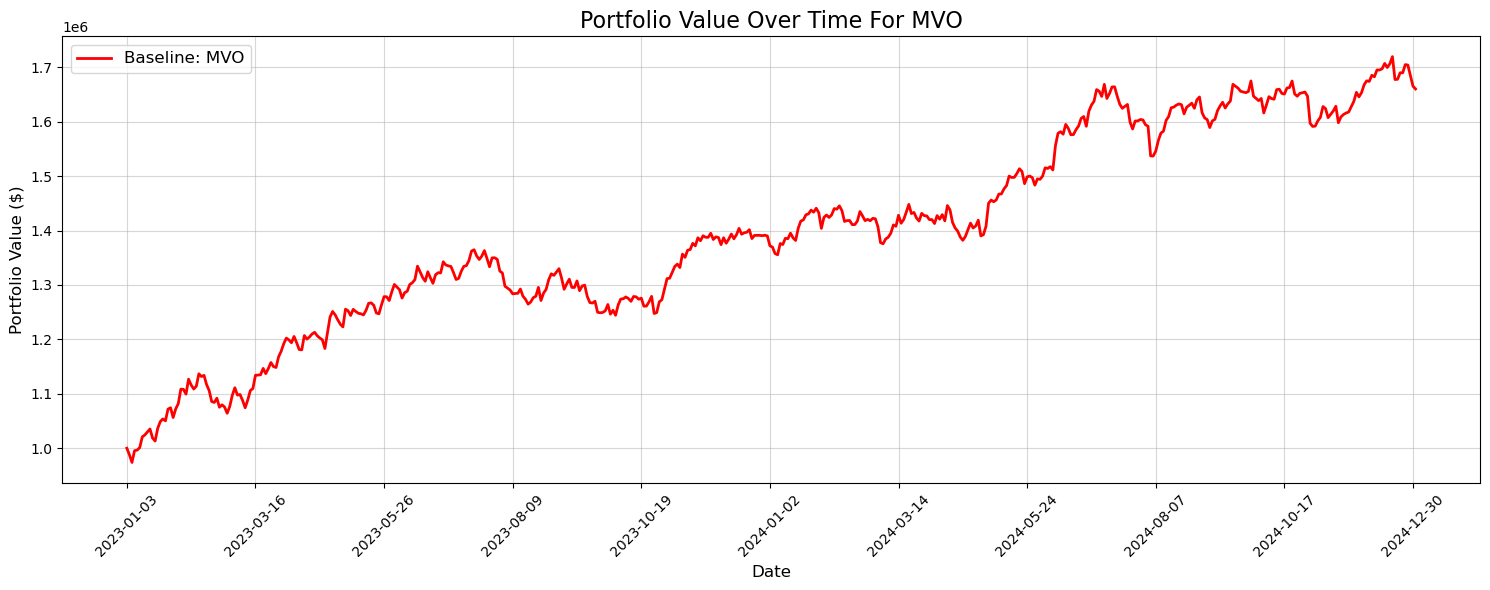

In [39]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(
    mvo_result["date"],
    mvo_result["MVO"],
    label="Baseline: MVO",
    linewidth=2,
    color="red"
)

plt.title("Portfolio Value Over Time For MVO", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Portfolio Value ($)", fontsize=12)
plt.legend(fontsize=12, loc="upper left")
plt.grid(True, alpha=0.5)

xticks_interval = max(1, len(mvo_result) // 10)
plt.xticks(mvo_result["date"][::xticks_interval], rotation=45)

plt.tight_layout()
plt.show()

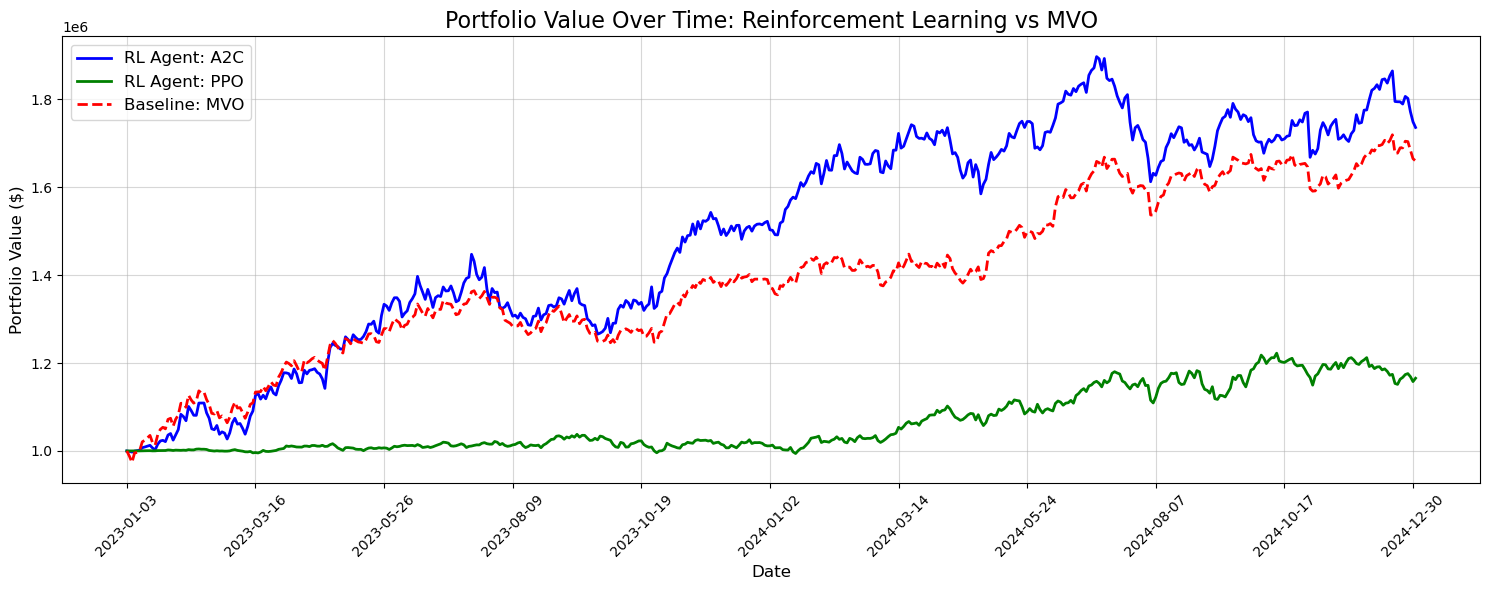

In [40]:
%matplotlib inline
import matplotlib.pyplot as plt


result_df = df_account_value_a2c[["date", "account_value"]].rename(columns={"account_value": "A2C"})
result_df = result_df.merge(df_account_value_ppo[["date", "account_value"]].rename(columns={"account_value": "PPO"}), on="date")
result_df = result_df.merge(mvo_result, on="date")


plt.figure(figsize=(15, 6))
plt.plot(result_df["date"], result_df["A2C"], label="RL Agent: A2C", linewidth=2, color="blue")
plt.plot(result_df["date"], result_df["PPO"], label="RL Agent: PPO", linewidth=2, color="green")
plt.plot(result_df["date"], result_df["MVO"], label="Baseline: MVO", linewidth=2, linestyle='--', color="red")

plt.title("Portfolio Value Over Time: Reinforcement Learning vs MVO", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Portfolio Value ($)", fontsize=12)
plt.legend(fontsize=12, loc="upper left")
plt.grid(True, alpha=0.5)

xticks_interval = max(1, len(result_df) // 10)
plt.xticks(result_df["date"][::xticks_interval], rotation=45)

plt.tight_layout()
plt.show()